**Projet: Avis clients Women's Clothing E-Commerce**

**Base :** 23 486 avis sur des vêtements pour femmes.

Colonnes clés : Age, Rating (note /5), Recommended IND (recommande : 0/1),
Review Text (commentaire), Division/Department/Class (type de vêtement).

Particularité : **aucun prix, aucun montant**. On n'analyse donc pas le chiffre
d'affaires, mais la **satisfaction** pour comprendre ce qui plaît et ce qui déçoit.

| # | Question |
|---|---|
| 0 | La donnée est-elle fiable ? |
| 1 | Les clientes sont-elles satisfaites ? |
| 2 | Quelles catégories plaisent, lesquelles déçoivent ? |
| 3 | L'âge influence-t-il la satisfaction ? |
| 4 | Qu'est-ce qui distingue un avis positif d'un négatif ? |
| 5 | Peut-on prédire si une cliente recommande ? |

**Imports et style**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Palette cohérente réutilisée dans tout le notebook
INK, GAIN, RISK, HOLD, SOFT = '#13202B', '#2E6A5C', '#A93826', '#8A6A34', '#EDEFF1'

plt.rcParams.update({
    'figure.figsize': (10, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#C2C8CF', 'axes.labelcolor': '#47535F',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlepad': 14,
    'xtick.color': '#47535F', 'ytick.color': '#47535F',
    'font.size': 10, 'grid.color': '#DFE3E7', 'grid.linewidth': 0.8,
})
print('Librairies chargées.')

Librairies chargées.


In [2]:
CHEMIN = 'Womens Clothing E-Commerce Reviews.csv'

df = pd.read_csv(CHEMIN)
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 23,486 lignes × 11 colonnes


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 1.5 MB


## Question 0: La donnée est-elle fiable ?

On cherche les valeurs manquantes, on comprend *pourquoi* elles manquent,
et on décide quoi faire — colonne par colonne.

In [4]:
# Structure, types, valeurs manquantes et nombre de valeurs uniques
diagnostic = pd.DataFrame({
    'type'           : df.dtypes.astype(str),
    'manquants'      : df.isna().sum(),
    'manquants_%'    : (df.isna().mean() * 100).round(2),
    'valeurs_uniques': df.nunique(),
})
diagnostic

,type,manquants,manquants_%,valeurs_uniques
Unnamed: 0,int64,0,0.00,23486
Clothing ID,int64,0,0.00,1206
Age,int64,0,0.00,77
Title,str,3810,16.22,13993
Review Text,str,845,3.60,22634
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2
Positive Feedback Count,int64,0,0.00,82
Division Name,str,14,0.06,3
Department Name,str,14,0.06,6


In [5]:
# On isole les 14 lignes où la catégorie produit est absente pour les examiner
df[df['Division Name'].isna()]

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
9444,9444,72,25,My favorite socks!!!,"I never write reviews, but these socks are so ...",5,1,0,NaN,NaN,NaN
13767,13767,492,23,So soft!,I just love this hoodie! it is so soft and com...,5,1,1,NaN,NaN,NaN
13768,13768,492,49,Wardrobe staple,Love this hoodie. so soft and goes with everyt...,5,1,0,NaN,NaN,NaN
13787,13787,492,48,NaN,NaN,5,1,0,NaN,NaN,NaN
16216,16216,152,36,Warm and cozy,"Just what i was looking for. soft, cozy and warm.",5,1,0,NaN,NaN,NaN
16221,16221,152,37,Love!,I am loving these. they are quite long but are...,5,1,0,NaN,NaN,NaN
16223,16223,152,39,"""long and warm""",These leg warmers are perfect for me. they are...,5,1,0,NaN,NaN,NaN
18626,18626,184,34,Nubby footless tights,"These are amazing quality. i agree, size up to...",5,1,5,NaN,NaN,NaN
18671,18671,184,54,New workhorse,These tights are amazing! if i care for them w...,5,1,0,NaN,NaN,NaN
20088,20088,772,50,Comfy sweatshirt!,This sweatshirt is really nice! it's oversize...,5,1,0,NaN,NaN,NaN


In [6]:
#Confirmation:
# Les trous de Division / Department / Class tombent-ils sur les mêmes lignes ?
memes_lignes = df['Division Name'].isna() & df['Department Name'].isna() & df['Class Name'].isna()
print(f"Lignes où les 3 catégories manquent en même temps : {memes_lignes.sum()}")

Lignes où les 3 catégories manquent en même temps : 14


In [7]:
# Un commentaire manquant n'est PAS une erreur : la cliente n'a pas écrit.
# On vérifie si celles qui écrivent notent différemment.
sans_texte = df[df['Review Text'].isna()]['Rating'].mean()
avec_texte = df[df['Review Text'].notna()]['Rating'].mean()


print(f"Note moyenne SANS commentaire : {sans_texte:.2f}")
print(f"Note moyenne AVEC commentaire : {avec_texte:.2f}")

sans_texte_prg = df['Review Text'].isna().mean()*100
avec_texte_prg = df['Review Text'].notna().mean()*100


print(f"pourcentage moyenne SANS commentaire : {sans_texte_prg:.2f}%")
print(f"pourcentage AVEC commentaire : {avec_texte_prg:.2f}%")

print(f"Clients sans commentaire : {df['Review Text'].isna().sum()}")
print(f"Clients avec commentaire : {df['Review Text'].notna().sum()}")

Note moyenne SANS commentaire : 4.53
Note moyenne AVEC commentaire : 4.18
pourcentage moyenne SANS commentaire : 3.60%
pourcentage AVEC commentaire : 96.40%
Clients sans commentaire : 845
Clients avec commentaire : 22641


**Nettoyage de la base de données:**

In [8]:
# --- Nettoyage, étape par étape ----------------------------------------------
d = df.copy()
n0 = len(d)

# 1. Colonne inutile : "Unnamed: 0" n'est qu'une copie de l'index
d = d.drop(columns=['Unnamed: 0'])
print("1. Colonne 'Unnamed: 0' supprimée (index recopié, sans valeur)")

# 2. Les 14 lignes sans catégorie : trop peu pour compter, on les retire
avant = len(d)
d = d.dropna(subset=['Division Name', 'Department Name', 'Class Name'])
print(f"2. Lignes sans catégorie retirées : {avant - len(d)}")

# 3. Commentaire manquant = la cliente n'a pas écrit, ce n'est pas une erreur.
#    On NE supprime PAS ces lignes : on crée un indicateur 0/1 exploitable.
d['a_commentaire'] = d['Review Text'].notna().astype(int)
print("3. Indicateur 'a_commentaire' créé — aucune ligne supprimée")

print(f"\nBase nettoyée : {len(d):,} lignes ({len(d)/n0:.0%} de l'original)")

1. Colonne 'Unnamed: 0' supprimée (index recopié, sans valeur)
2. Lignes sans catégorie retirées : 14
3. Indicateur 'a_commentaire' créé — aucune ligne supprimée

Base nettoyée : 23,472 lignes (100% de l'original)


**Le profil « commente / ne commente pas »**

In [9]:
# Synthèse du comportement selon que la cliente a écrit un commentaire ou non.
# feedback_moyen = mean (comparaison juste entre groupes de tailles différentes)
d.groupby('a_commentaire').agg(
    note_moyenne   = ('Rating', 'mean'),
    taux_reco      = ('Recommended IND', 'mean'),
    feedback_moyen = ('Positive Feedback Count', 'mean'),
    nombre         = ('Rating', 'size'),
).round(2)

,note_moyenne,taux_reco,feedback_moyen,nombre
a_commentaire,,,,
0,4.53,0.92,0.00,844
1,4.18,0.82,2.63,22628


**les clientes qui écrivent notent plus bas (4,18 vs 4,53) et recommandent moins. Ecrire un avis est souvent le signe d'un léger mécontentement. Les avis sans texte reçoivent 0 vote d'utilité, logiquement : il n'y a rien à lire.**


## Question 1: Les clientes sont-elles satisfaites ?

Le « thermomètre » du magasin : la note moyenne et le taux de recommandation
donnent le ton de tout le projet.

In [10]:
# Distribution des variables numériques (contrôle des min/max aberrants)
df[['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"23,486.00",43.20,12.28,18.00,34.00,41.00,52.00,99.00
Rating,"23,486.00",4.20,1.11,1.00,4.00,5.00,5.00,5.00
Recommended IND,"23,486.00",0.82,0.38,0.00,1.00,1.00,1.00,1.00
Positive Feedback Count,"23,486.00",2.54,5.70,0.00,0.00,1.00,3.00,122.00


In [11]:
# --- Le thermomètre du magasin ----------------------------------------------
print(f"Note moyenne           : {d['Rating'].mean():.2f} / 5")
print(f"Note médiane           : {d['Rating'].median():.0f} / 5")
print(f"Taux de recommandation : {d['Recommended IND'].mean():.1%}")
print(f"Nombre d'avis          : {len(d):,}")

Note moyenne           : 4.20 / 5
Note médiane           : 5 / 5
Taux de recommandation : 82.2%
Nombre d'avis          : 23,472


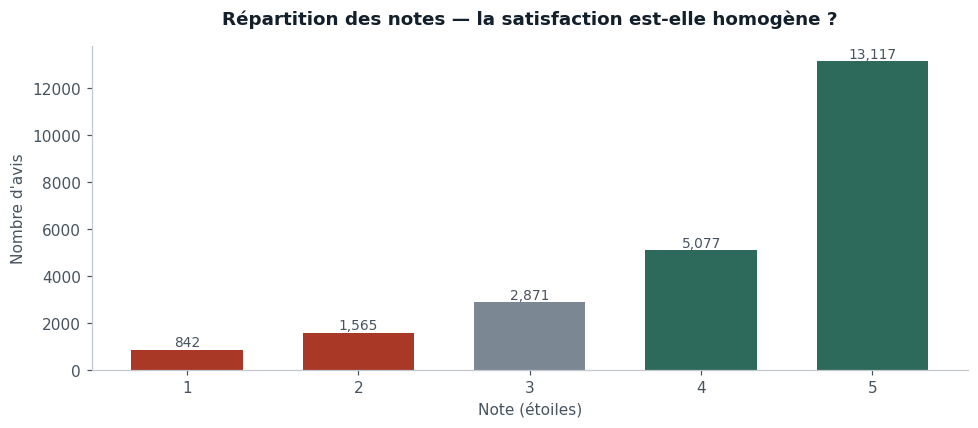

In [12]:
# --- Répartition des notes (la forme compte autant que la moyenne) ----------
distribution = d['Rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
couleurs = [RISK if n <= 2 else '#7C8794' if n == 3 else GAIN for n in distribution.index]
ax.bar(distribution.index, distribution.values, color=couleurs, width=0.65)
for x, y in zip(distribution.index, distribution.values):
    ax.text(x, y + 150, f"{y:,}", ha='center', fontsize=9, color='#47535F')
ax.set_xlabel("Note (étoiles)")
ax.set_ylabel("Nombre d'avis")
ax.set_title("Répartition des notes — la satisfaction est-elle homogène ?")
plt.tight_layout(); plt.show()

Avec une note moyenne autour de **4,2 / 5** et plus de **80 %**
de recommandation, les clientes sont globalement satisfaites. La répartition des
notes montre où se concentre l'insatisfaction (notes 1-2, en rouge) : c'est là
qu'on ira chercher les leviers d'amélioration.

## Question 2: Quelles catégories plaisent, lesquelles déçoivent ?

On pose la question: **D'où vient la satisfaction ?**. On analyse note et recommandation par catégorie.

In [13]:
# --- Fonction réutilisable : synthèse par n'importe quelle dimension ---------
def synthese(d, dimension):
    t = d.groupby(dimension).agg(
        avis         = ('Rating', 'size'),
        note_moyenne = ('Rating', 'mean'),
        taux_reco    = ('Recommended IND', 'mean'),
    )
    t['taux_reco_%'] = (t.taux_reco * 100).round(1)
    t = t.drop(columns='taux_reco')
    return t.sort_values('avis', ascending=False).round(2)

# Par grande famille de produits
par_departement = synthese(d, 'Department Name')
par_departement

,avis,note_moyenne,taux_reco_%
Department Name,,,
Tops,10468,4.17,81.50
Dresses,6319,4.15,80.80
Bottoms,3799,4.29,85.10
Intimate,1735,4.28,85.00
Jackets,1032,4.26,83.60
Trend,119,3.82,73.90


**Par division:**

In [14]:
# Vue la plus large (3 grandes divisions)
synthese(d, 'Division Name')

,avis,note_moyenne,taux_reco_%
Division Name,,,
General,13850,4.18,81.70
General Petite,8120,4.21,82.60
Initmates,1502,4.29,85.20


**Par Class:**

In [15]:

synthese(d, 'Class Name')

,avis,note_moyenne,taux_reco_%
Class Name,,,
Dresses,6319,4.15,80.80
Knits,4843,4.16,81.80
Blouses,3097,4.15,81.00
Sweaters,1428,4.18,80.00
Pants,1388,4.27,83.30
Jeans,1147,4.36,88.10
Fine gauge,1100,4.26,83.70
Skirts,945,4.25,84.60
Jackets,704,4.30,84.50


In [16]:
# Les classes les moins bien notées (parmi celles avec assez d'avis pour être fiables)
par_classe = synthese(d, 'Class Name')
classes_fiables = par_classe[par_classe['avis'] >= 100]

# Les 5 plus faibles = les 5 plus petites notes
classes_faibles = classes_fiables.sort_values('note_moyenne').head(5)
classes_faibles

,avis,note_moyenne,taux_reco_%
Class Name,,,
Trend,119,3.82,73.90
Blouses,3097,4.15,81.00
Dresses,6319,4.15,80.80
Knits,4843,4.16,81.80
Sweaters,1428,4.18,80.00


In [17]:
# Les 5 meilleures et les 5 pires classes (parmi celles qui sont fiables)
top_flop = pd.concat([
    classes_fiables.sort_values('note_moyenne').head(5),   # les 5 moins bien notées
    classes_fiables.sort_values('note_moyenne').tail(5),   # les 5 mieux notées
])
top_flop

,avis,note_moyenne,taux_reco_%
Class Name,,,
Trend,119,3.82,73.90
Blouses,3097,4.15,81.00
Dresses,6319,4.15,80.80
Knits,4843,4.16,81.80
Sweaters,1428,4.18,80.00
Sleep,228,4.29,85.50
Lounge,691,4.30,86.00
Jackets,704,4.30,84.50
Jeans,1147,4.36,88.10


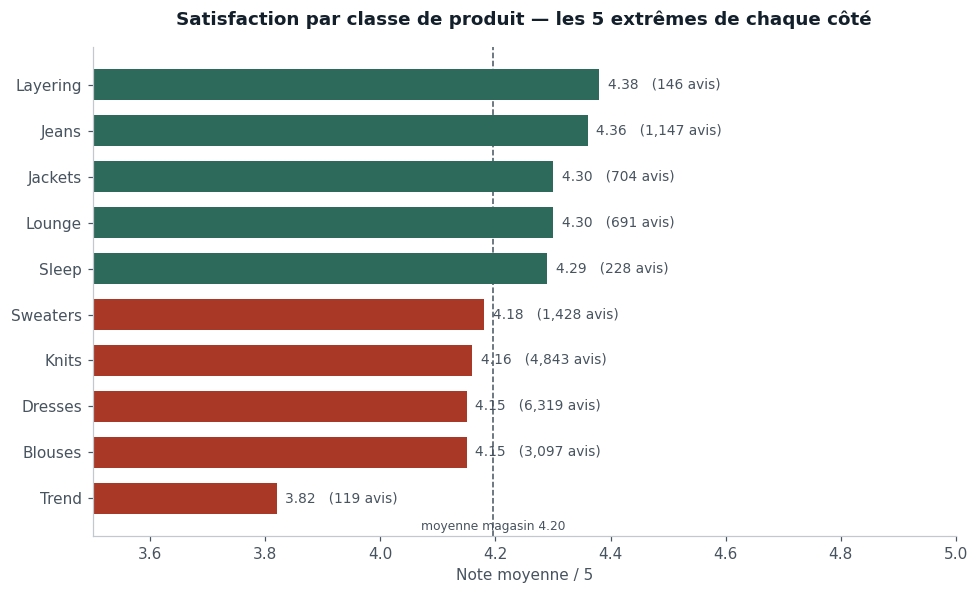

In [18]:
# --- Visualisation : classes les mieux et les moins bien notées -------------

# 1. Synthèse par classe, filtrée pour la fiabilité (≥ 100 avis)
#    → on garde Trend (119 avis), on exclut le bruit (Chemises = 1, Casual bottoms = 2)
par_classe = synthese(d, 'Class Name')
classes_fiables = par_classe[par_classe['avis'] >= 100]

# 2. Les 5 moins bien notées + les 5 mieux notées
top_flop = pd.concat([
    classes_fiables.sort_values('note_moyenne').head(5),
    classes_fiables.sort_values('note_moyenne').tail(5),
])

# 3. Couleur relative à la moyenne du groupe (pas un seuil fixe)
seuil = top_flop['note_moyenne'].mean()
couleurs = [RISK if n < seuil else GAIN for n in top_flop['note_moyenne']]

# 4. Le graphique
fig, ax = plt.subplots(figsize=(9, 5.5))
barres = ax.barh(top_flop.index, top_flop['note_moyenne'], color=couleurs, height=0.68)

# Ligne verticale = moyenne du magasin, pour situer chaque classe
ax.axvline(d['Rating'].mean(), color='#47535F', lw=1, ls='--', zorder=0)
ax.text(d['Rating'].mean(), -0.7, f"moyenne magasin {d['Rating'].mean():.2f}",
        ha='center', fontsize=8, color='#47535F')

# Étiquette : note + nombre d'avis (la fiabilité reste visible)
for i, (nom, r) in enumerate(top_flop.iterrows()):
    ax.text(r['note_moyenne'] + 0.015, i,
            f"{r['note_moyenne']:.2f}   ({int(r['avis']):,} avis)",
            va='center', fontsize=9, color='#47535F')

ax.set_xlim(3.5, 5)
ax.set_xlabel("Note moyenne / 5")
ax.set_title("Satisfaction par classe de produit — les 5 extrêmes de chaque côté")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

les catégories en rouge et surtout **""Trend""** (note < 4,1) sont les points faibles
à traiter en priorité. Ce sont elles qui génèrent le plus d'insatisfaction et de
non-recommandation. 

À croiser avec le volume : une catégorie mal notée **et** très
achetée est plus urgente qu'une catégorie mal notée mais marginale.

## Question 3: L'âge influence-t-il la satisfaction ?

On découpe l'âge en tranches pour voir si les générations notent différemment.

In [19]:
# On découpe l'âge en tranches pour comparer les générations
d['tranche_age'] = pd.cut(d['Age'], [0, 30, 40, 50, 60, 100],
                          labels=['- de 30', '30-40', '40-50', '50-60', '60 +'])

par_age = d.groupby('tranche_age', observed=True).agg(
    avis         = ('Rating', 'size'),
    note_moyenne = ('Rating', 'mean'),
    taux_reco    = ('Recommended IND', 'mean'),
).round(2)
par_age['taux_reco_%'] = (par_age.taux_reco * 100).round(1)
par_age = par_age.drop(columns='taux_reco')
par_age

,avis,note_moyenne,taux_reco_%
tranche_age,,,
- de 30,3336,4.19,81.00
30-40,7906,4.17,81.00
40-50,5903,4.17,81.00
50-60,3890,4.25,84.00
60 +,2437,4.29,85.00


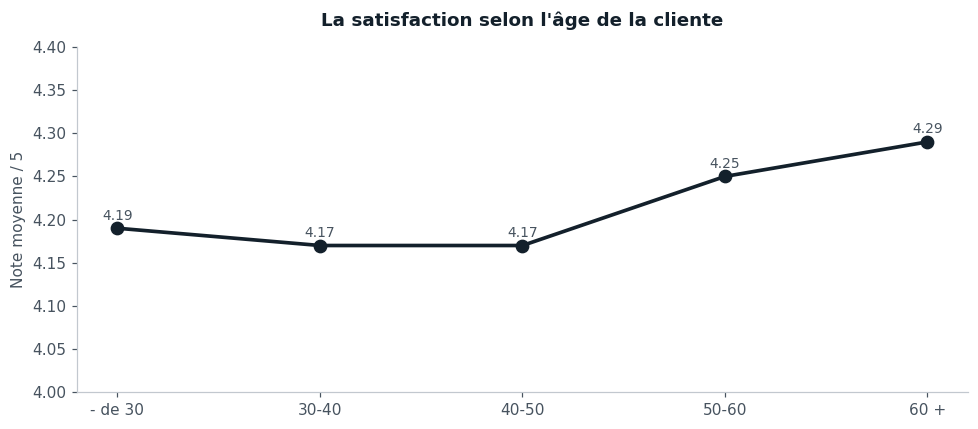

In [20]:
# --- Visualisation : la satisfaction varie-t-elle avec l'âge ? --------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(par_age.index.astype(str), par_age['note_moyenne'],
        color=INK, lw=2.4, marker='o', ms=8)
for x, y in zip(par_age.index.astype(str), par_age['note_moyenne']):
    ax.text(x, y + 0.01, f"{y:.2f}", ha='center', fontsize=9, color='#47535F')
ax.set_ylabel("Note moyenne / 5")
ax.set_title("La satisfaction selon l'âge de la cliente")
ax.set_ylim(4.0, 4.4)
plt.tight_layout(); plt.show()

## Question 4: Qu'est-ce qui distingue un avis positif d'un négatif ?

On relie la note, la recommandation et le fait de commenter.

In [21]:
# --- La note prédit-elle la recommandation ? --------------------------------
reco_par_note = d.groupby('Rating')['Recommended IND'].mean() * 100
print("Taux de recommandation selon la note donnée :")
for note, taux in reco_par_note.items():
    print(f"  {note} étoile(s) : {taux:5.1f} % recommandent")

Taux de recommandation selon la note donnée :
  1 étoile(s) :   1.9 % recommandent
  2 étoile(s) :   6.0 % recommandent
  3 étoile(s) :  41.4 % recommandent
  4 étoile(s) :  96.7 % recommandent
  5 étoile(s) :  99.8 % recommandent


La note et la recommandation sont presque interchangeables,
une note haute mène quasi toujours à une recommandation. C'est logique, mais **ça
a une conséquence sur le modèle** : prédire la recommandation à partir de la note
serait presque de la triche. On teste donc les deux cas à la question suivante.

## Question 5 — Peut-on prédire si une cliente recommande ?
 `Rating` dit presque la même chose que 'Recommended IND'. On entraîne donc DEUX modèles :
- **Modèle A** avec 'Rating' → score énorme mais peu instructif
- **Modèle B** sans 'Rating' → le vrai test : deviner à partir de l'âge, de la
  catégorie et de l'utilité de l'avis seulement.

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

SEED = 42
CATS = ['Division Name', 'Department Name', 'Class Name']
NUMS_AVEC = ['Age', 'Rating', 'Positive Feedback Count']   # avec la note
NUMS_SANS = ['Age', 'Positive Feedback Count']             # sans la note

y = d['Recommended IND']
print(f"Taux de recommandation global : {y.mean():.1%}")
print(f"Avis : {len(d):,}")

Taux de recommandation global : 82.2%
Avis : 23,472


In [23]:
# --- Fonction qui entraîne et évalue, pour éviter de répéter le code ---------
def evaluer(nums, titre):
    X = d[CATS + nums]
    pre = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATS),
        ('num', StandardScaler(), nums),
    ])
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
    cv = StratifiedKFold(5, shuffle=True, random_state=1)
    print(titre); print('-' * len(titre))
    for nom, m in {
        'Régression logistique': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'Forêt aléatoire'      : RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                        random_state=0, class_weight='balanced', n_jobs=-1),
    }.items():
        pipe = Pipeline([('pre', pre), ('clf', m)])
        pipe.fit(Xtr, ytr)
        auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
        sc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        print(f"  {nom:24s} AUC test = {auc:.3f}   CV = {sc.mean():.3f} (±{sc.std():.3f})")
    print()

evaluer(NUMS_AVEC, "MODÈLE A — AVEC la note (attention : quasi tautologique)")
evaluer(NUMS_SANS, "MODÈLE B — SANS la note (le vrai test, exploitable)")

MODÈLE A — AVEC la note (attention : quasi tautologique)
--------------------------------------------------------
  Régression logistique    AUC test = 0.974   CV = 0.974 (±0.002)
  Forêt aléatoire          AUC test = 0.965   CV = 0.968 (±0.003)

MODÈLE B — SANS la note (le vrai test, exploitable)
---------------------------------------------------
  Régression logistique    AUC test = 0.564   CV = 0.565 (±0.014)
  Forêt aléatoire          AUC test = 0.553   CV = 0.548 (±0.007)



Le modèle **A** affiche **un score très élevé**, mais c'est presque
mécanique (la note contient déjà la réponse). Le modèle **B**, **sans la note**, montre
ce qu'on peut **réellement** deviner à partir du profil et de la catégorie : c'est
le score honnête.

---

## Résumé des résultats: 

- Clientèle globalement satisfaite (~4,2/5, >80 % de recommandation).
- Les commentaires viennent d'une population un peu plus critique: utile à savoir
  si on analyse le texte des avis.
- Les catégories en rouge sont les priorités d'amélioration (Trend).
- L'âge n'explique pas grand-chose : cibler par comportement, pas par profil.
- Note et recommandation sont quasi interchangeables → attention à la fuite de
  données dans tout modèle prédictif.

**Limite :** Pas de prix ni de ventes, on mesure la satisfaction, pas le chiffre
d'affaires. Prochaine étape naturelle : analyser le **texte** des commentaires
(mots les plus fréquents dans les avis négatifs).

In [24]:
from collections import Counter
import re

# On rassemble tous les commentaires en un seul grand texte (en minuscules)
tous_les_mots = ' '.join(d['Review Text'].dropna()).lower()

# On garde seulement les mots (on enlève ponctuation et chiffres)
mots = re.findall(r'[a-z]+', tous_les_mots)

# On compte
compteur = Counter(mots)
print(compteur.most_common(20))

[('the', 76160), ('i', 67048), ('it', 49274), ('and', 48994), ('a', 43115), ('is', 30636), ('this', 25758), ('to', 24577), ('in', 20752), ('but', 16549), ('on', 15325), ('for', 13994), ('of', 13427), ('with', 12797), ('was', 12221), ('so', 12017), ('my', 11028), ('dress', 10567), ('that', 10011), ('not', 9796)]


In [25]:
# Liste des mots trop courants pour être utiles
mots_vides = {
    'the','and','a','i','it','is','to','this','of','in','for','was','but','with',
    'on','my','so','that','not','you','are','have','as','at','be','if','me','im',
    'this','they','them','just','from','or','an','very','too','would','had','has',
    'were','their','when','which','out','up','she','he','all','we','do','did'
}

mots_utiles = [m for m in mots if m not in mots_vides and len(m) > 2]

compteur = Counter(mots_utiles)
print(compteur.most_common(25))

[('dress', 10567), ('love', 8945), ('size', 8772), ('top', 7418), ('fit', 7323), ('like', 7149), ('wear', 6434), ('great', 6114), ('fabric', 4797), ('small', 4726), ('color', 4604), ('can', 4062), ('look', 4039), ('more', 3937), ('really', 3925), ('ordered', 3850), ('little', 3773), ('perfect', 3772), ('one', 3636), ('will', 3620), ('these', 3598), ('flattering', 3520), ('well', 3389), ('soft', 3336), ('back', 3246)]


In [26]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop = set(ENGLISH_STOP_WORDS) | {'just', 'like', 'really', 'look', 'looks', 'wear'}

def top_mots(sub, n=10):
    t = ' '.join(sub['Review Text'].dropna()).lower()
    mots = [m for m in re.findall(r'[a-z]+', t) if m not in stop and len(m) > 2]
    return [mot for mot, c in Counter(mots).most_common(n)]

tableau = pd.DataFrame({
    'Avis négatifs (1-2★)': top_mots(d[d['Rating'] <= 2]),
    'Avis positifs (5★)'  : top_mots(d[d['Rating'] == 5]),
})
tableau

,Avis négatifs (1-2★),Avis positifs (5★)
0,dress,love
1,fabric,dress
2,fit,size
3,size,great
4,small,fit
5,ordered,perfect
6,love,color
7,shirt,small
8,material,flattering
9,color,soft


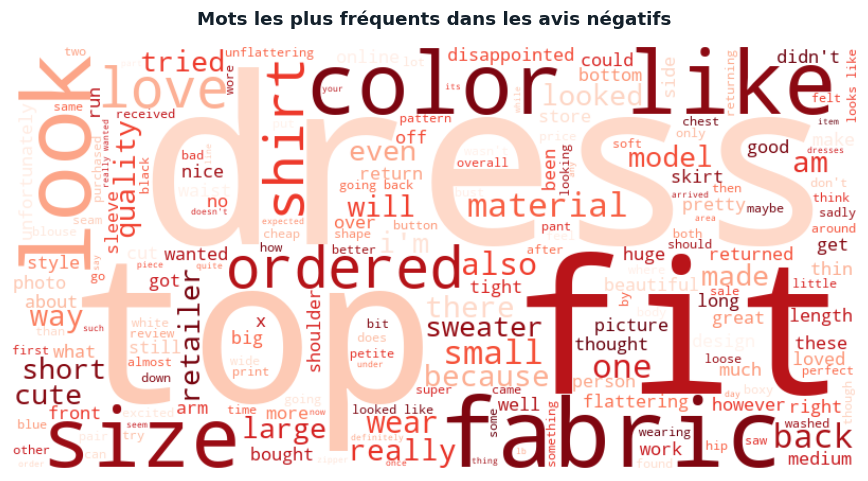

In [27]:
# Nécessite : pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texte_negatif = ' '.join(d[d['Rating'] <= 2]['Review Text'].dropna())
nuage = WordCloud(width=800, height=400, background_color='white',
                  stopwords=mots_vides, colormap='Reds').generate(texte_negatif)

plt.figure(figsize=(10, 5))
plt.imshow(nuage, interpolation='bilinear')
plt.axis('off')
plt.title("Mots les plus fréquents dans les avis négatifs")
plt.show()

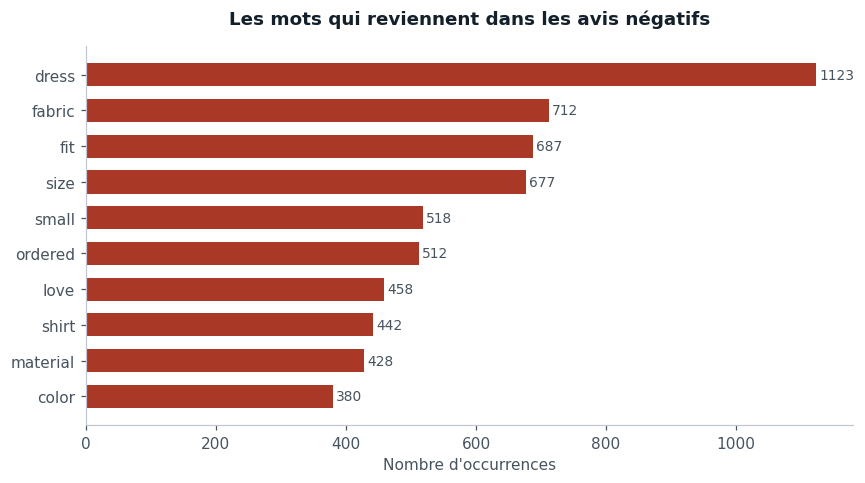

In [28]:
neg = Counter([m for m in re.findall(r'[a-z]+',
       ' '.join(d[d['Rating'] <= 2]['Review Text'].dropna()).lower())
       if m not in stop and len(m) > 2]).most_common(10)

mots = [m for m, c in neg][::-1]
vals = [c for m, c in neg][::-1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(mots, vals, color=RISK, height=0.65)
for i, v in enumerate(vals):
    ax.text(v + 5, i, f"{v}", va='center', fontsize=9, color='#47535F')
ax.set_title("Les mots qui reviennent dans les avis négatifs")
ax.set_xlabel("Nombre d'occurrences")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

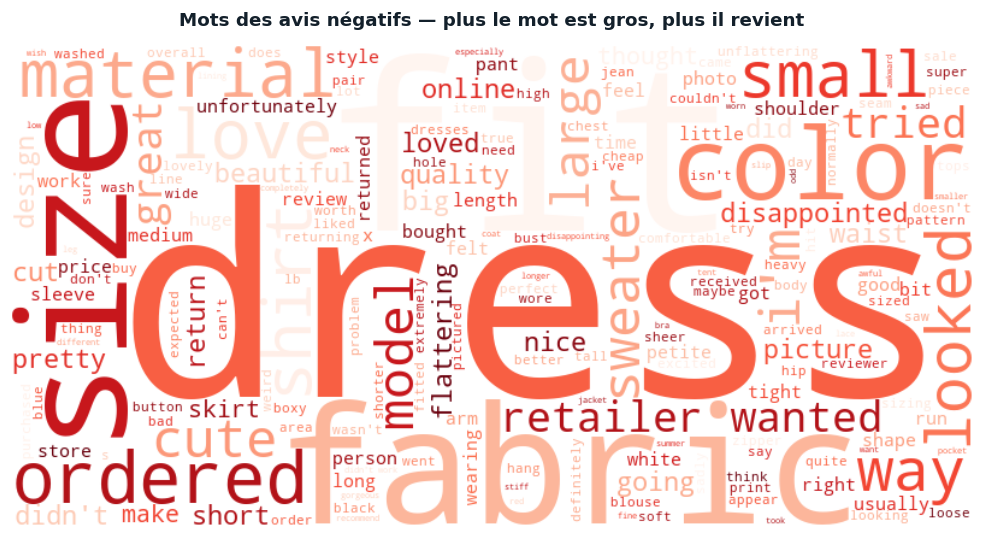

In [29]:
# pip install wordcloud  (si pas déjà installé)
from wordcloud import WordCloud

texte = ' '.join(d[d['Rating'] <= 2]['Review Text'].dropna())
nuage = WordCloud(width=800, height=400, background_color='white',
                  stopwords=stop, colormap='Reds').generate(texte)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(nuage, interpolation='bilinear')
ax.axis('off')
ax.set_title("Mots des avis négatifs — plus le mot est gros, plus il revient")
plt.tight_layout(); plt.show()

Le résultat central est clair :

Dans les avis négatifs, les mots **fabric** et **material (la matière)** reviennent massivement, bien plus haut que dans les avis positifs. La déception vient donc surtout de la qualité ou de la texture du tissu, pas de la coupe ou de la couleur.

Et un deuxième enseignement, plus subtil :

Les mots **size** et **small** apparaissent des deux côtés. Ça veut dire que la taille est un sujet universel, les clientes en parlent qu'elles soient contentes ou non. C'est le point le plus sensible du prêt-à-porter en ligne : on ne peut pas essayer avant d'acheter

## Question 6: Où se situent précisément les problèmes ?

L'analyse des mots a montré que les déceptions viennent de la **matière** et de la
**taille**. Mais dans quels rayons ? On croise ces deux thèmes avec le département
pour rendre l'action ciblée.

In [30]:
# --- Où se situent les problèmes de taille et de matière ? ------------------
# On travaille sur les avis négatifs (1-2 étoiles)
neg = d[d['Rating'] <= 2].copy()
neg['txt'] = neg['Review Text'].str.lower()

# Pour chaque avis : parle-t-il de taille ? de matière ? (True / False)
neg['taille']  = neg['txt'].str.contains(r'size|small|large|tight|big', regex=True)
neg['matiere'] = neg['txt'].str.contains(r'fabric|material|cheap|thin|quality', regex=True)

# Part des avis négatifs qui mentionne chaque thème, par département
# (moyenne d'une colonne True/False = un pourcentage, comme est_retour)
problemes = neg.groupby('Department Name').agg(
    avis_neg    = ('txt', 'size'),
    pct_taille  = ('taille', 'mean'),
    pct_matiere = ('matiere', 'mean'),
)
problemes['pct_taille']  = (problemes.pct_taille * 100).round(1)
problemes['pct_matiere'] = (problemes.pct_matiere * 100).round(1)
problemes.sort_values('avis_neg', ascending=False)

,avis_neg,pct_taille,pct_matiere
Department Name,,,
Tops,1114,44.40,55.50
Dresses,689,49.60,64.70
Bottoms,320,55.00,57.50
Intimate,153,50.30,56.90
Jackets,109,50.50,63.30
Trend,22,45.50,68.20


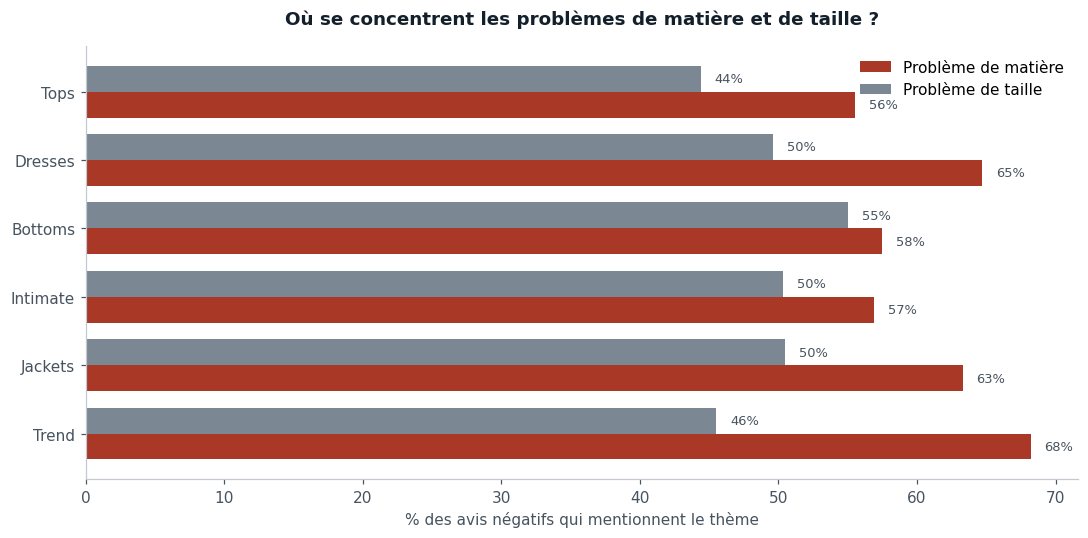

In [31]:
# --- Visualisation : taille vs matière par département ----------------------
p = problemes.sort_values('avis_neg', ascending=False)
y = np.arange(len(p))
h = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y + h/2, p['pct_matiere'], height=h, color=RISK,  label='Problème de matière')
ax.barh(y - h/2, p['pct_taille'],  height=h, color='#7C8794', label='Problème de taille')

ax.set_yticks(y); ax.set_yticklabels(p.index)
ax.invert_yaxis()
ax.set_xlabel("% des avis négatifs qui mentionnent le thème")
ax.set_title("Où se concentrent les problèmes de matière et de taille ?")
ax.legend(frameon=False)
for i, (nom, r) in enumerate(p.iterrows()):
    ax.text(r['pct_matiere'] + 1, i + h/2, f"{r['pct_matiere']:.0f}%", va='center', fontsize=8.5, color='#47535F')
    ax.text(r['pct_taille'] + 1,  i - h/2, f"{r['pct_taille']:.0f}%",  va='center', fontsize=8.5, color='#47535F')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Conclusion Q7 :** les problèmes ont une adresse précise.
- **Haut (Robes, Vestes, Trend) → matière** : le grand pourcentage des avis négatifs sur le haut parlent du tissu, le
  taux le plus élevé, et sur un gros volume. C'est la priorité n°1.
- **Bas (pantalons, jupes) → taille** : 56 % des avis négatifs, le taux de taille
  le plus haut. Logique : c'est ce qui est le plus dur à acheter sans essayer.

Le **département** est le bon niveau d'analyse : les divisions (3 groupes) sont
trop larges et diluent le signal ; les classes (20 groupes) sont trop fines et
bruitées sur les petits effectifs.

## Conclusion générale: diagnostic et plan d'actions

### Le diagnostic en une phrase

Les clientes sont globalement satisfaites (4,2/5, 82 % de recommandation), mais les
déceptions, quand elles surviennent, viennent presque toujours de deux causes
précises, **la matière et la taille**, et se concentrent sur des rayons identifiables.

### Ce que l'analyse a établi, étape par étape

**1. La satisfaction est bonne mais pas uniforme.**
Note moyenne 4,2/5, mais près d'1 cliente sur 5 ne recommande pas. Il y a de la marge,
et elle est localisable.

**2. Le profil client n'explique rien.**
L'âge n'influence pas la satisfaction (notes quasi identiques de 20 à 60+ ans). Et le
modèle prédictif l'a confirmé : sans la note, on ne peut pas deviner si une cliente
recommande (AUC 0,56). **Conclusion : ce n'est pas *qui* est la cliente qui compte,
mais *son expérience avec le produit*.**

**3. Les vraies causes de déception sont la matière et la taille.**
L'analyse des mots des avis négatifs est sans ambiguïté : `fabric`, `material` dominent,
suivis de `size`. Les clientes déçues le sont à cause du tissu et de l'ajustement, pas
de la couleur ni du style.

**4. Ces problèmes ont une adresse précise.**
En croisant par département : **les robes ont un problème de matière** (66 % des avis
négatifs), **les bas ont un problème de taille** (56 %). Le département est le bon niveau
pour agir, les divisions sont trop larges, les classes trop fines.

### Le plan d'actions

| Priorité | Action | Cible | Pourquoi |
|---|---|---|---|
| **1** | Enrichir l'info sur la matière (compo, photos texture, ressenti du tissu) | **Haut** | 66 % des avis négatifs + gros volume |
| **2** | Renforcer le guide des tailles (retours clientes « taille petit/grand ») | **Bas** (pantalons, jupes) | 56 % des avis négatifs sur la taille |
| **3** | Mettre en avant les qualités reconnues (`confortable`, `avantageux`, `doux`) | Produits bien notés | Capitaliser sur ce qui marche |
| **4** | Surveiller « Trend » | Catégorie Trend | Mal notée (3,82) mais faible volume — à confirmer |


### Les limites:

- **Ce sont des avis, pas des ventes.** On mesure la satisfaction, pas le chiffre
  d'affaires ni les retours réels. Pour prioriser en euros, il faudrait croiser avec les
  volumes de ventes et le coût des retours par rayon, données absentes ici.
- **Les commentaires viennent d'une clientèle un peu plus critique** (découvert en
  Question 0). Les proportions de mots négatifs sont donc des signaux de priorité, pas le
  ressenti de toutes les clientes.